In [1]:
# [setup]
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE_DIR = 'data-official/comparisons/no-iran'

ACCOUNTING_DATE = pd.Timestamp('2026-12-15')
PLOT_START = pd.Timestamp('2025-10-01')
PLOT_END = pd.Timestamp('2027-01-01')

# Datasets: 02-27 baseline + active variants
FORECAST_FILES = {
    '02-27 (baseline)':  f'{BASE_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    # '04-01 (default)':   f'{BASE_DIR}/2026-04-01/mozaic_daily_forecast.2026-04-01.gm+ld-D.parquet',
    # '04-01 (cps=0.01)':  f'{BASE_DIR}/2026-04-01_cps0.01/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (cps=0.015)': f'{BASE_DIR}/2026-04-01_cps0.015/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (cps=0.02)':  f'{BASE_DIR}/2026-04-01_cps0.02/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (cps=0.03)':  f'{BASE_DIR}/2026-04-01_cps0.03/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-06 (cps=0.02)':  f'{BASE_DIR}/2026-04-06_cps0.02/mozaic_daily_forecast.2026-04-06.gm-D.parquet',
    # '04-06 (cps=0.02 DEPM)': f'{BASE_DIR}/2026-04-06_cps0.02_depm/mozaic_daily_forecast.2026-04-06.gm-D.parquet',
    # '04-01 (cps=0.02 clip0.7)': f'{BASE_DIR}/2026-04-01_cps0.02_clip0.7/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (cps=0.02 clip1)': f'{BASE_DIR}/2026-04-01_cps0.02_clip1/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (clip1 thresh025)': f'{BASE_DIR}/2026-04-01_cps0.02_clip1_thresh025/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (thresh025)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh025/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (clip0.3 thresh025)': f'{BASE_DIR}/2026-04-01_cps0.02_clip0.3_thresh025/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    '04-01 (thresh03)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh03/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (thresh035)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh035/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (thresh035 recent)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh035_recent/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    '04-01 (thresh035 recent13)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh035_recent13/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (thresh02 recent13)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh02_recent13/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    # '04-01 (thresh03 recent13)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh03_recent13/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    '04-01 (thresh032 recent13)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh032_recent13/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
    '04-01 (thresh033 recent13)': f'{BASE_DIR}/2026-04-01_cps0.02_thresh033_recent13/mozaic_daily_forecast.2026-04-01.gm-D.parquet',
}

DATASET_STYLES = {
    '02-27 (baseline)':            {'color': '#E65100', 'linestyle': '-',  'linewidth': 2.0},
    '04-01 (thresh03)':            {'color': '#9C27B0', 'linestyle': '-',  'linewidth': 1.6},
    '04-01 (thresh035 recent13)':  {'color': '#1565C0', 'linestyle': '--', 'linewidth': 1.6},
    '04-01 (thresh032 recent13)':  {'color': '#2E7D32', 'linestyle': '--', 'linewidth': 1.6},
    '04-01 (thresh033 recent13)':  {'color': '#C62828', 'linestyle': '--', 'linewidth': 1.6},
}

print('Setup complete.')


Setup complete.


In [2]:
# [load-data]
def extract_world_mobile_dau(path):
    """Load world-level mobile DAU from a forecast parquet file.

    Filters to country='ALL', data_source='glean_mobile', app_name='ALL MOBILE'.
    Returns DataFrame with columns: target_date, dau, data_type.
    """
    df = pd.read_parquet(path)
    mask = (
        (df['country'] == 'ALL')
        & (df['data_source'] == 'glean_mobile')
        & (df['segment'] == '{}')
        & (df['app_name'] == 'ALL MOBILE')
    )
    result = df.loc[mask, ['target_date', 'dau', 'data_type']].copy()
    result['target_date'] = pd.to_datetime(result['target_date'])
    result = result.sort_values('target_date').reset_index(drop=True)
    assert len(result) > 0, f'No rows matched: {path}'
    return result


mobile_data = {}
for key, path in FORECAST_FILES.items():
    mobile_data[key] = extract_world_mobile_dau(path)
    date_range = f"{mobile_data[key]['target_date'].min().date()} to {mobile_data[key]['target_date'].max().date()}"
    print(f'{key:22s}: {len(mobile_data[key]):>5} rows  [{date_range}]')

02-27 (baseline)      :  2557 rows  [2020-12-31 to 2027-12-31]
04-01 (thresh03)      :  2557 rows  [2020-12-31 to 2027-12-31]
04-01 (thresh035 recent13):  2557 rows  [2020-12-31 to 2027-12-31]
04-01 (thresh032 recent13):  2557 rows  [2020-12-31 to 2027-12-31]
04-01 (thresh033 recent13):  2557 rows  [2020-12-31 to 2027-12-31]


In [3]:
# [helpers]
def add_ma28(df, value_col='dau'):
    """Return a copy of df with a 'dau_ma28' column (28-day trailing mean)."""
    df = df.copy().sort_values('target_date')
    df['dau_ma28'] = df[value_col].rolling(28, min_periods=28).mean()
    return df


def trim(df, start=PLOT_START, end=PLOT_END, date_col='target_date'):
    """Filter df to [start, end] on the given date column."""
    return df[(df[date_col] >= start) & (df[date_col] <= end)].copy()


def millions_formatter(x, pos):
    return f'{x / 1e6:.1f}M'


def mark_accounting_date(ax):
    ax.axvline(ACCOUNTING_DATE, color='black', linestyle='--', alpha=0.35, linewidth=1)
    ymin, ymax = ax.get_ylim()
    ax.text(ACCOUNTING_DATE, ymax, '  Dec 15', va='top', ha='left', fontsize=8, alpha=0.55)


def apply_date_axis(ax):
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')


print('Helpers defined.')

Helpers defined.


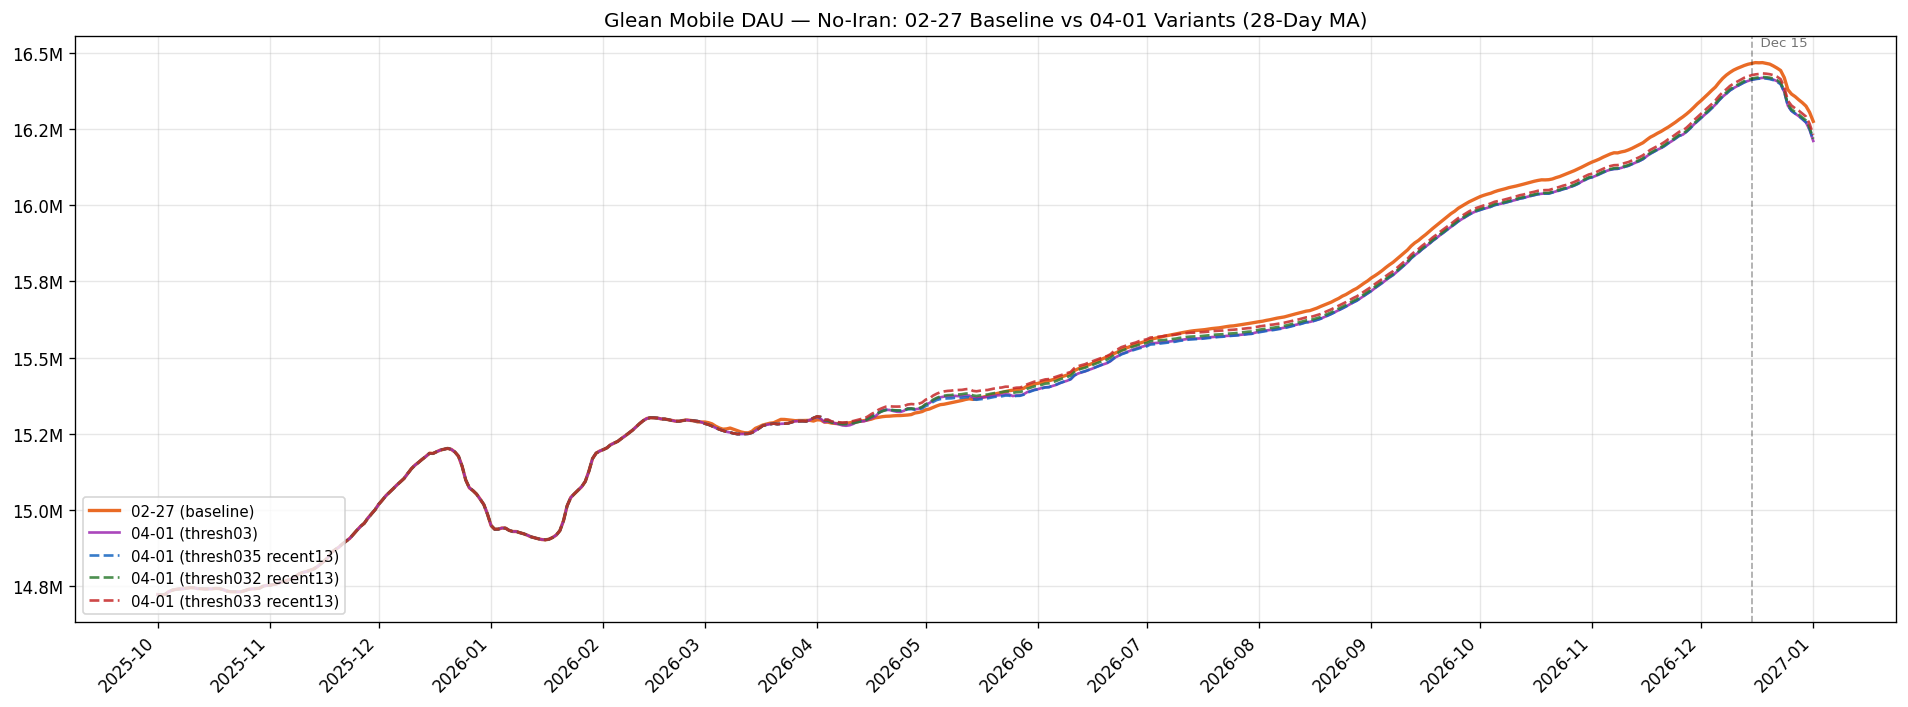

In [4]:
# [plot-all-variants]
fig, ax = plt.subplots(figsize=(16, 6))

for key in FORECAST_FILES:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(mobile_data[key])
    df_plot = trim(df_ma)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU \u2014 No-Iran: 02-27 Baseline vs 04-01 Variants (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()

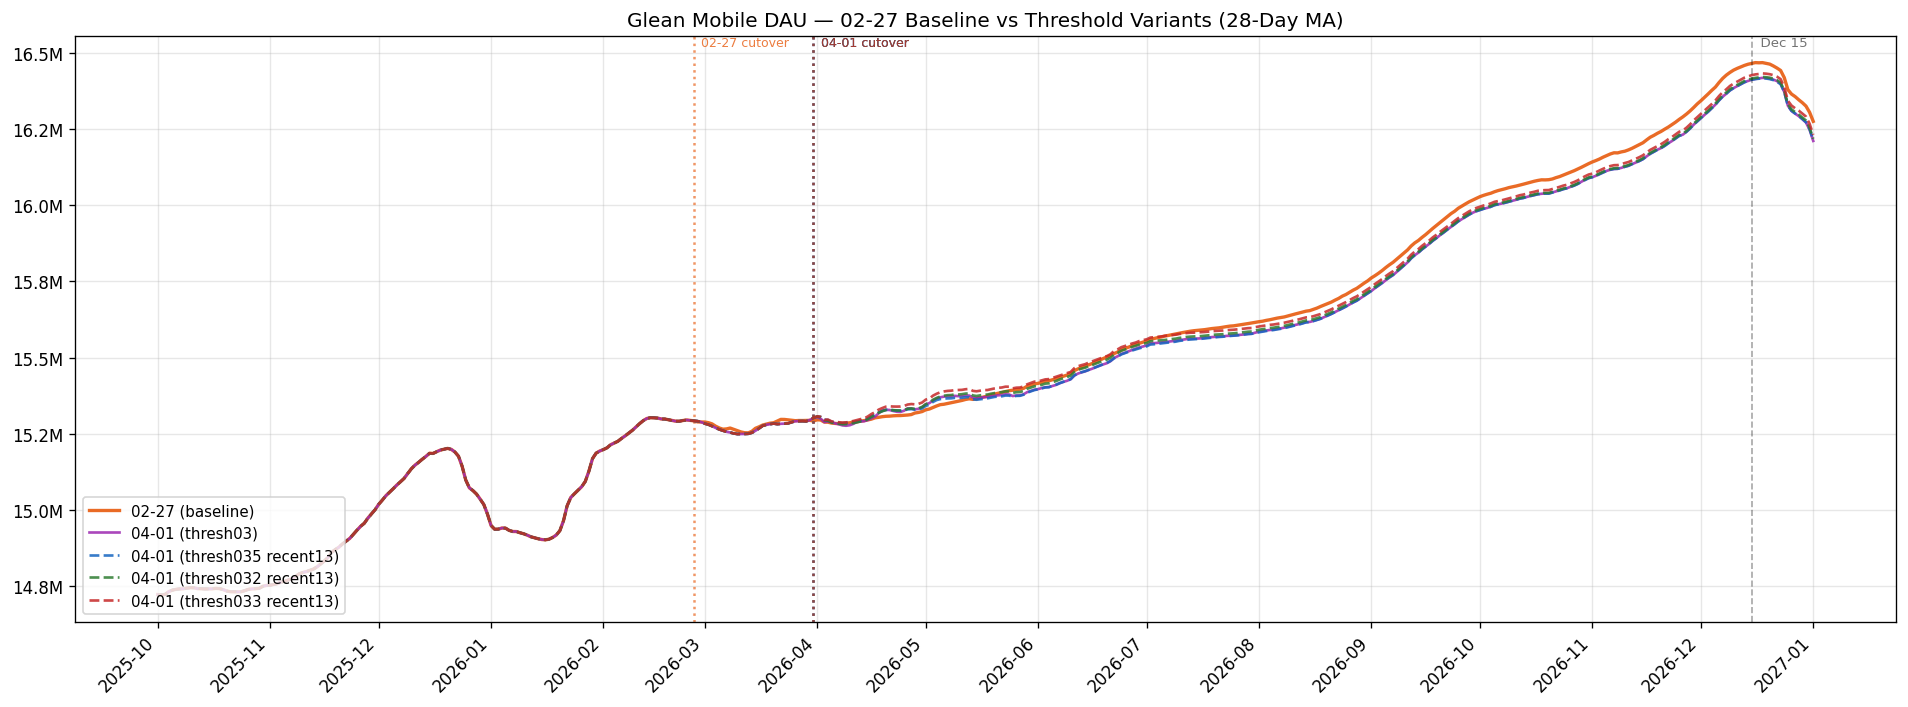

In [5]:
# [plot-baseline-vs-cps015]
FOCUS_KEYS = ['02-27 (baseline)', '04-01 (thresh03)', '04-01 (thresh035 recent13)', '04-01 (thresh032 recent13)', '04-01 (thresh033 recent13)']
FOCUS_COLORS = {
    '02-27 (baseline)':            '#E65100',
    '04-01 (thresh03)':            '#9C27B0',
    '04-01 (thresh035 recent13)':  '#1565C0',
    '04-01 (thresh032 recent13)':  '#2E7D32',
    '04-01 (thresh033 recent13)':  '#C62828',
}

fig, ax = plt.subplots(figsize=(16, 6))

for key in FOCUS_KEYS:
    style = DATASET_STYLES[key]
    df_full = mobile_data[key].copy()
    df_ma = add_ma28(df_full)
    df_plot = trim(df_ma)

    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

    # Vertical line at the last historical (training/actual) date
    boundary = df_full.loc[
        df_full['data_type'].isin(['training', 'actual']),
        'target_date'
    ].max()
    if pd.notna(boundary):
        ax.axvline(boundary, color=style['color'], linestyle=':',
                   linewidth=1.5, alpha=0.6)
        ymin, ymax = ax.get_ylim()
        ax.text(boundary + pd.Timedelta(days=2), ymax,
                f'{key[:5]} cutover',
                va='top', ha='left', fontsize=7.5, color=style['color'], alpha=0.75)

ax.set_title('Glean Mobile DAU \u2014 02-27 Baseline vs Threshold Variants (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()


In [6]:
# [ma28-on-apr05]
SNAPSHOT_DATE = pd.Timestamp('2026-04-05')

print(f'28-day MA on {SNAPSHOT_DATE.date()}:')
print()
for key in FORECAST_FILES:
    df_ma = add_ma28(mobile_data[key])
    row = df_ma.loc[df_ma['target_date'] == SNAPSHOT_DATE]
    if len(row) == 0:
        print(f'  {key:22s}:  no data for this date')
    else:
        val = row['dau_ma28'].values[0]
        print(f'  {key:22s}:  {val:>14,.0f}')


28-day MA on 2026-04-05:

  02-27 (baseline)      :      15,284,656
  04-01 (thresh03)      :      15,287,719
  04-01 (thresh035 recent13):      15,288,738
  04-01 (thresh032 recent13):      15,285,990
  04-01 (thresh033 recent13):      15,290,305


In [7]:
# [summary-stats]
baseline_key = '02-27 (baseline)'
baseline_ma = add_ma28(mobile_data[baseline_key])

rows = []
for key in FORECAST_FILES:
    if key == baseline_key:
        continue
    df_ma = add_ma28(mobile_data[key])

    # Merge on target_date to compare MA28 values
    merged = baseline_ma[['target_date', 'dau_ma28']].merge(
        df_ma[['target_date', 'dau_ma28']],
        on='target_date', suffixes=('_baseline', '_variant')
    ).dropna()

    # Restrict to the plot window
    merged = merged[
        (merged['target_date'] >= PLOT_START)
        & (merged['target_date'] <= PLOT_END)
    ]

    diff = merged['dau_ma28_variant'] - merged['dau_ma28_baseline']
    pct_diff = 100 * diff / merged['dau_ma28_baseline']

    # Value at Dec 15 accounting date
    dec15 = merged.loc[merged['target_date'] == ACCOUNTING_DATE]
    dec15_baseline = dec15['dau_ma28_baseline'].values[0] if len(dec15) else np.nan
    dec15_variant = dec15['dau_ma28_variant'].values[0] if len(dec15) else np.nan
    dec15_diff = dec15_variant - dec15_baseline if not np.isnan(dec15_baseline) else np.nan
    dec15_pct = 100 * dec15_diff / dec15_baseline if not np.isnan(dec15_baseline) else np.nan

    rows.append({
        'variant': key,
        'mean_diff': diff.mean(),
        'mean_pct_diff': pct_diff.mean(),
        'max_abs_diff': diff.abs().max(),
        'max_abs_pct_diff': pct_diff.abs().max(),
        'dec15_baseline_ma28': dec15_baseline,
        'dec15_variant_ma28': dec15_variant,
        'dec15_diff': dec15_diff,
        'dec15_pct_diff': dec15_pct,
    })

summary = pd.DataFrame(rows)

print('=== Summary: each variant vs 02-27 baseline (28-day MA, plot window) ===')
print()
for _, row in summary.iterrows():
    print(f"  {row['variant']}")
    print(f"    Mean diff:      {row['mean_diff']:>12,.0f}  ({row['mean_pct_diff']:+.2f}%)")
    print(f"    Max |diff|:     {row['max_abs_diff']:>12,.0f}  ({row['max_abs_pct_diff']:.2f}%)")
    print(f"    Dec 15 MA28:    {row['dec15_variant_ma28']:>12,.0f}  vs baseline {row['dec15_baseline_ma28']:,.0f}  ({row['dec15_pct_diff']:+.2f}%)")
    print()

# Dec 15 comparison table
print('=== Dec 15 MA28 Comparison ===')
print()
baseline_dec15_row = baseline_ma.loc[baseline_ma['target_date'] == ACCOUNTING_DATE]
baseline_dec15_val = baseline_dec15_row['dau_ma28'].values[0] if len(baseline_dec15_row) else np.nan

header = f"  {'Variant':<30s}  {'MA28':>14s}  {'Diff':>12s}  {'Pct':>8s}"
print(header)
print(f"  {'-'*30}  {'-'*14}  {'-'*12}  {'-'*8}")
print(f"  {'02-27 (baseline)':<30s}  {baseline_dec15_val:>14,.0f}  {'—':>12s}  {'—':>8s}")
for _, row in summary.iterrows():
    print(f"  {row['variant']:<30s}  {row['dec15_variant_ma28']:>14,.0f}  {row['dec15_diff']:>+12,.0f}  {row['dec15_pct_diff']:>+7.2f}%")
print()


=== Summary: each variant vs 02-27 baseline (28-day MA, plot window) ===

  04-01 (thresh03)
    Mean diff:           -18,329  (-0.11%)
    Max |diff|:           64,374  (0.40%)
    Dec 15 MA28:      16,413,300  vs baseline 16,466,795  (-0.32%)

  04-01 (thresh035 recent13)
    Mean diff:           -18,618  (-0.12%)
    Max |diff|:           61,523  (0.38%)
    Dec 15 MA28:      16,413,058  vs baseline 16,466,795  (-0.33%)

  04-01 (thresh032 recent13)
    Mean diff:           -15,258  (-0.09%)
    Max |diff|:           57,340  (0.35%)
    Dec 15 MA28:      16,416,911  vs baseline 16,466,795  (-0.30%)

  04-01 (thresh033 recent13)
    Mean diff:            -8,784  (-0.05%)
    Max |diff|:           46,603  (0.28%)
    Dec 15 MA28:      16,428,145  vs baseline 16,466,795  (-0.23%)

=== Dec 15 MA28 Comparison ===

  Variant                                   MA28          Diff       Pct
  ------------------------------  --------------  ------------  --------
  02-27 (baseline)            

In [527]:
16401363 - 16466795

-65432

In [8]:
# [query-actuals]
# Query BQ for actual world-level mobile DAU (all apps combined, excluding Iran).
import time
from pathlib import Path
from google.cloud import bigquery

PROJECT = "moz-fx-data-bq-data-science"
CHECKPOINT_DIR = Path("data")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ACTUALS_END = "2026-04-12"

QUERY_MOBILE_ACTUALS = f"""
SELECT
    submission_date AS date,
    SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
  AND submission_date BETWEEN '2020-12-31' AND '{ACTUALS_END}'
  AND country != 'IR'
GROUP BY submission_date
ORDER BY 1
"""

checkpoint_actuals = CHECKPOINT_DIR / "compare_mobile_actuals_no_iran.parquet"
if checkpoint_actuals.exists():
    print(f"Loading checkpoint: {checkpoint_actuals}")
    df_actuals = pd.read_parquet(checkpoint_actuals)
    print(f"Loaded | Rows: {len(df_actuals):,} | {df_actuals['date'].min()} to {df_actuals['date'].max()}")
else:
    print("Querying BigQuery (mobile actuals, no Iran)...")
    t0 = time.time()
    df_actuals = bigquery.Client(PROJECT).query(QUERY_MOBILE_ACTUALS).to_dataframe()
    elapsed = time.time() - t0
    print(f"Query complete | {elapsed:.1f}s | Rows: {len(df_actuals):,}")
    df_actuals.to_parquet(checkpoint_actuals)
    print(f"Saved to {checkpoint_actuals}")

df_actuals['date'] = pd.to_datetime(df_actuals['date'])
df_actuals = df_actuals.sort_values('date').reset_index(drop=True)
df_actuals['dau_ma28'] = df_actuals['dau'].rolling(28, min_periods=28).mean()

print(f"\nDate range: {df_actuals['date'].min().date()} to {df_actuals['date'].max().date()}")
print(f"Last 5 days MA28:")
print(df_actuals[['date', 'dau', 'dau_ma28']].tail(5).to_string(index=False))


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Querying BigQuery (mobile actuals, no Iran)...


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Query complete | 20.0s | Rows: 1,928
Saved to data/compare_mobile_actuals_no_iran.parquet

Date range: 2020-12-31 to 2026-04-11
Last 5 days MA28:
      date      dau     dau_ma28
2026-04-07 15637395 1.528657e+07
2026-04-08 15669476 1.528924e+07
2026-04-09 15722657 1.529673e+07
2026-04-10 15686549 1.530699e+07
2026-04-11 15107848 1.531338e+07


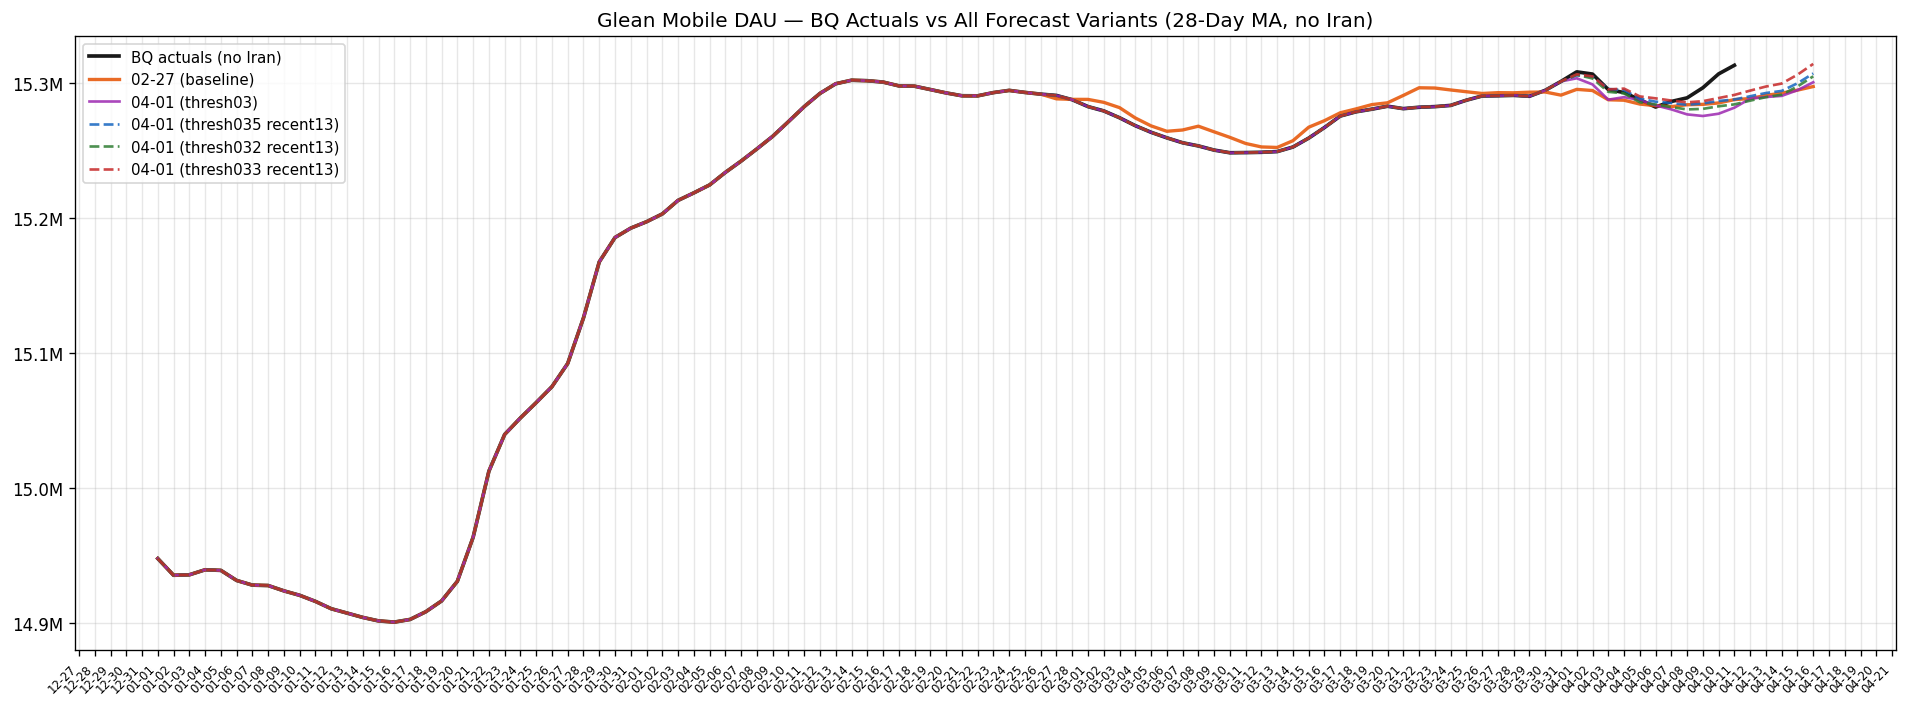

In [9]:
# [plot-actuals-vs-forecasts-long]
ZOOM_START = pd.Timestamp('2026-01-01')
ZOOM_END = pd.Timestamp('2026-04-16')

fig, ax = plt.subplots(figsize=(16, 6))

# Plot actuals (thick black line)
actuals_plot = df_actuals[
    (df_actuals['date'] >= ZOOM_START)
    & (df_actuals['date'] <= ZOOM_END)
]
ax.plot(actuals_plot['date'], actuals_plot['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

# Plot all forecast lines
for key in FORECAST_FILES:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(mobile_data[key])
    df_plot = trim(df_ma, start=ZOOM_START, end=ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals vs All Forecast Variants (28-Day MA, no Iran)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

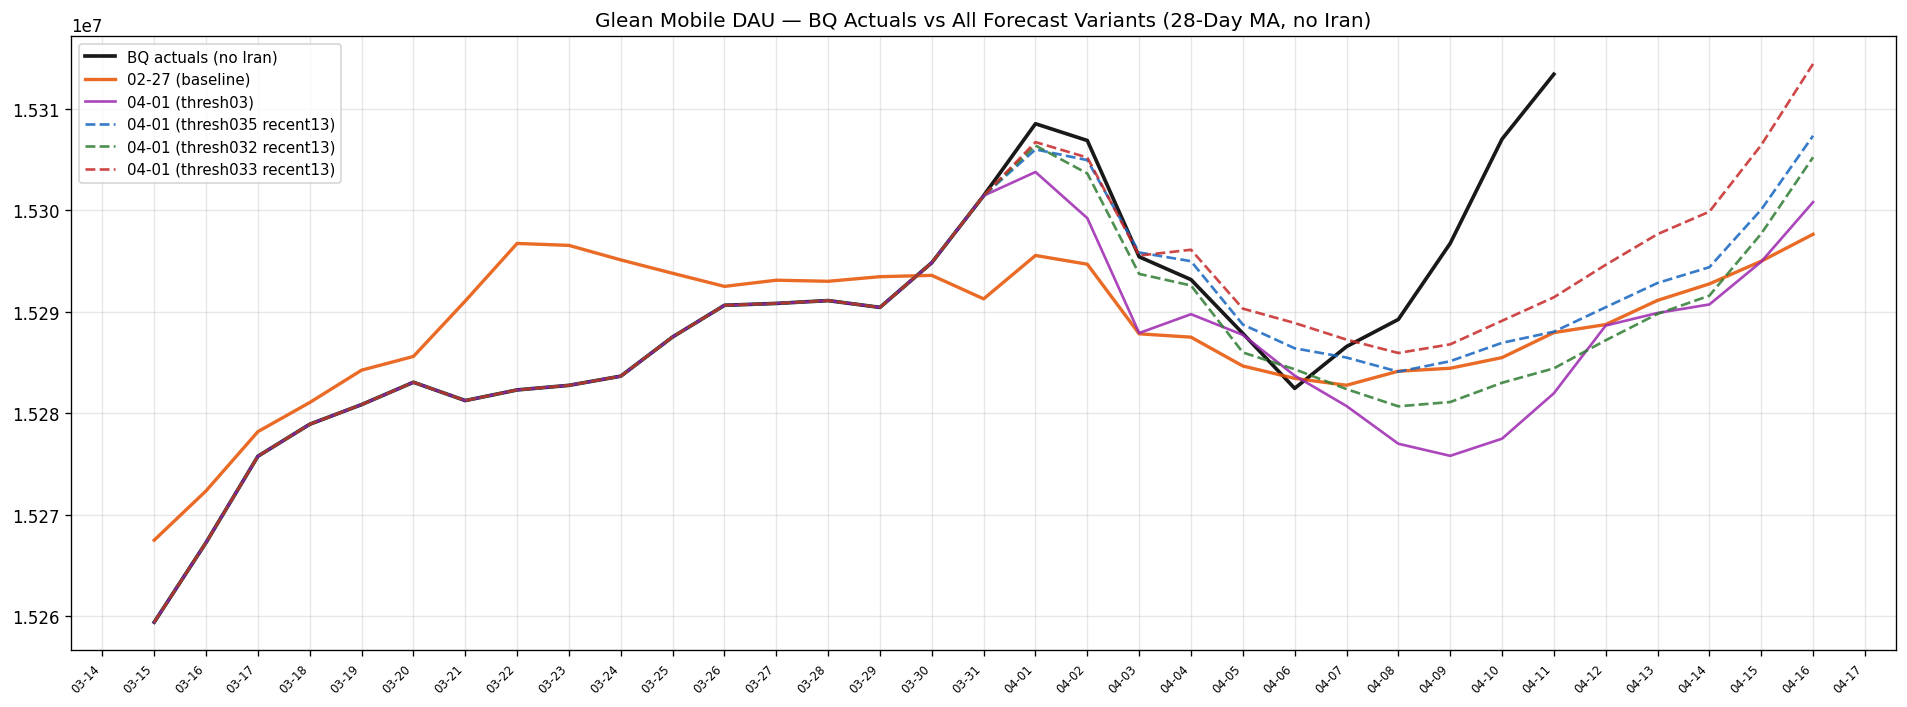

In [12]:
# [plot-actuals-vs-forecasts]
ZOOM_START = pd.Timestamp('2026-03-15')
ZOOM_END = pd.Timestamp('2026-04-16')

fig, ax = plt.subplots(figsize=(16, 6))

# Plot actuals (thick black line)
actuals_plot = df_actuals[
    (df_actuals['date'] >= ZOOM_START)
    & (df_actuals['date'] <= ZOOM_END)
]
ax.plot(actuals_plot['date'], actuals_plot['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

# Plot all forecast lines
for key in FORECAST_FILES:
    style = DATASET_STYLES[key]
    df_ma = add_ma28(mobile_data[key])
    df_plot = trim(df_ma, start=ZOOM_START, end=ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals vs All Forecast Variants (28-Day MA, no Iran)')
# ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


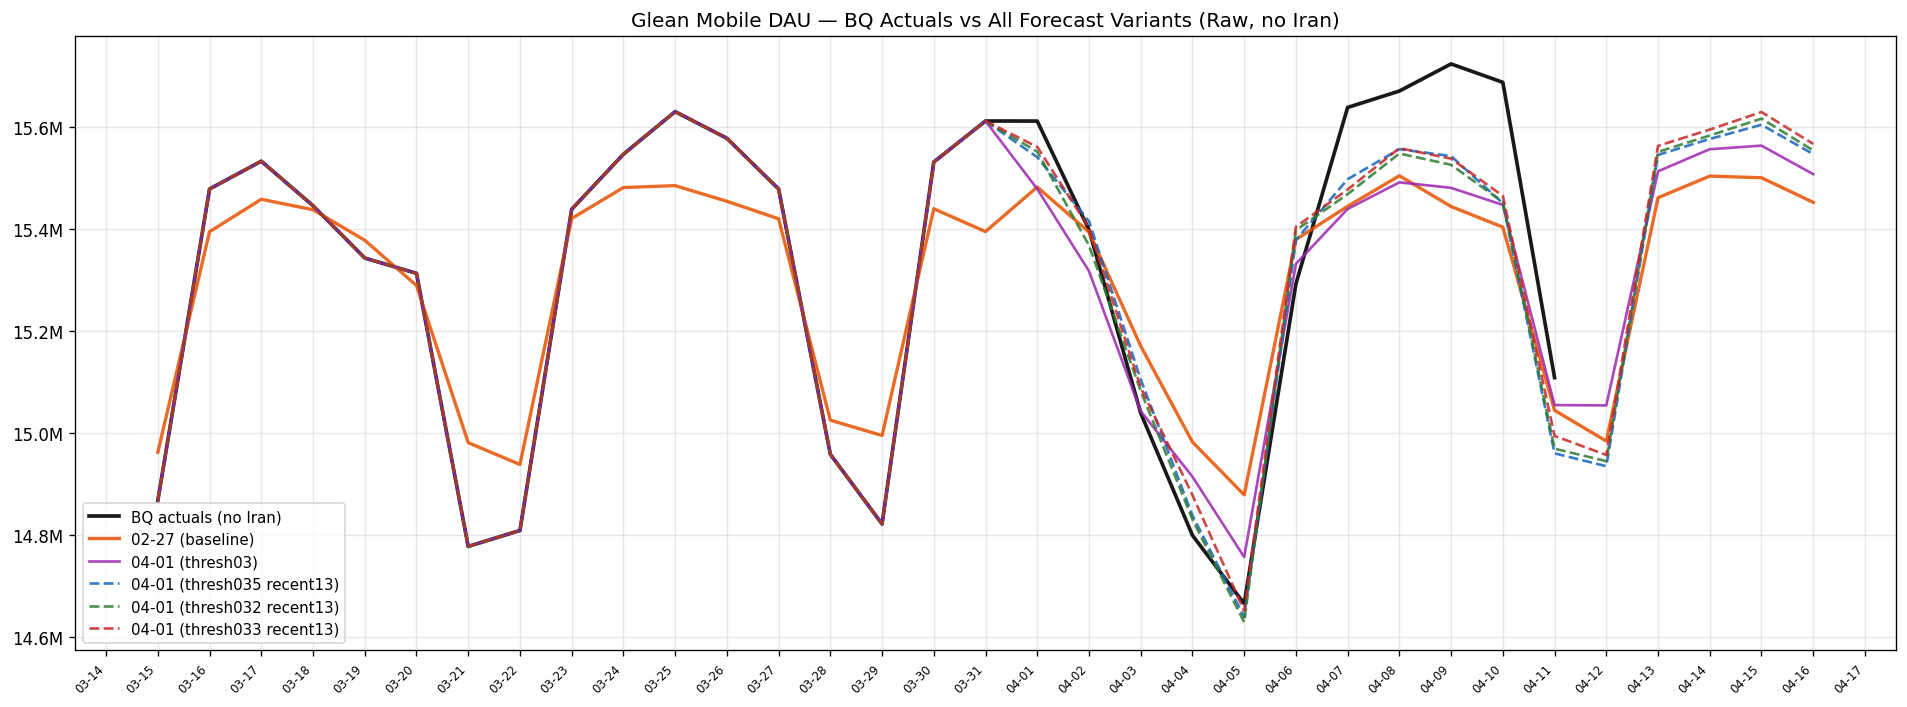

In [11]:
# [plot-actuals-raw]
fig, ax = plt.subplots(figsize=(16, 6))

# Actuals raw
actuals_zoom = df_actuals[
    (df_actuals['date'] >= ZOOM_START)
    & (df_actuals['date'] <= ZOOM_END)
]
ax.plot(actuals_zoom['date'], actuals_zoom['dau'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (no Iran)')

# All forecast variants raw
for key in FORECAST_FILES:
    style = DATASET_STYLES[key]
    df_plot = trim(mobile_data[key], start=ZOOM_START, end=ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals vs All Forecast Variants (Raw, no Iran)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


In [532]:
16420573- 16466795

-46222

In [533]:
# [load-country-data]
COUNTRY_VARIANTS = {
    '04-01 (thresh03)':            FORECAST_FILES['04-01 (thresh03)'],
    '04-01 (thresh035 recent13)':  FORECAST_FILES['04-01 (thresh035 recent13)'],
    '04-01 (thresh032 recent13)':  FORECAST_FILES['04-01 (thresh032 recent13)'],
    '04-01 (thresh033 recent13)':  FORECAST_FILES['04-01 (thresh033 recent13)'],
}

COUNTRY_STYLES = {
    '04-01 (thresh03)':            {'color': '#9C27B0', 'linestyle': '-',  'linewidth': 1.4},
    '04-01 (thresh035 recent13)':  {'color': '#1565C0', 'linestyle': '--', 'linewidth': 1.4},
    '04-01 (thresh032 recent13)':  {'color': '#2E7D32', 'linestyle': '--', 'linewidth': 1.4},
    '04-01 (thresh033 recent13)':  {'color': '#C62828', 'linestyle': '--', 'linewidth': 1.4},
}


def extract_country_mobile_dau(path):
    """Load per-country mobile DAU from a forecast parquet file.

    Filters to data_source='glean_mobile', app_name='ALL MOBILE', segment='{}',
    excludes country='ALL'. Returns DataFrame with columns:
    target_date, country, dau, data_type.
    """
    df = pd.read_parquet(path)
    mask = (
        (df['data_source'] == 'glean_mobile')
        & (df['app_name'] == 'ALL MOBILE')
        & (df['segment'] == '{}')
        & (df['country'] != 'ALL')
    )
    result = df.loc[mask, ['target_date', 'country', 'dau', 'data_type']].copy()
    result['target_date'] = pd.to_datetime(result['target_date'])
    result = result.sort_values(['country', 'target_date']).reset_index(drop=True)
    assert len(result) > 0, f'No rows matched: {path}'
    return result


country_data = {}
for key, path in COUNTRY_VARIANTS.items():
    country_data[key] = extract_country_mobile_dau(path)
    countries = sorted(country_data[key]['country'].unique())
    print(f'{key:30s}: {len(country_data[key]):>6} rows | {len(countries)} countries: {", ".join(countries)}')


04-01 (thresh03)              :  38355 rows | 15 countries: AR, BR, CA, CN, DE, FR, ID, IN, IT, JP, MX, PL, ROW, RU, US
04-01 (thresh035 recent13)    :  38355 rows | 15 countries: AR, BR, CA, CN, DE, FR, ID, IN, IT, JP, MX, PL, ROW, RU, US
04-01 (thresh032 recent13)    :  38355 rows | 15 countries: AR, BR, CA, CN, DE, FR, ID, IN, IT, JP, MX, PL, ROW, RU, US
04-01 (thresh033 recent13)    :  38355 rows | 15 countries: AR, BR, CA, CN, DE, FR, ID, IN, IT, JP, MX, PL, ROW, RU, US


In [534]:
# [query-country-actuals]
import time
from pathlib import Path
from google.cloud import bigquery

CHECKPOINT_DIR = Path("data")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_ACTUALS_END = "2026-04-06"

QUERY_COUNTRY_ACTUALS = f"""
SELECT
    submission_date AS date,
    country,
    SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
  AND submission_date BETWEEN '2020-12-31' AND '{COUNTRY_ACTUALS_END}'
  AND country != 'IR'
GROUP BY submission_date, country
ORDER BY 1, 2
"""

checkpoint_country_actuals = CHECKPOINT_DIR / "compare_country_actuals_no_iran.parquet"
if checkpoint_country_actuals.exists():
    print(f"Loading checkpoint: {checkpoint_country_actuals}")
    df_country_actuals = pd.read_parquet(checkpoint_country_actuals)
    print(f"Loaded | Rows: {len(df_country_actuals):,} | {df_country_actuals['date'].min()} to {df_country_actuals['date'].max()}")
else:
    print("Querying BigQuery (country-level mobile actuals, no Iran)...")
    t0 = time.time()
    df_country_actuals = bigquery.Client(PROJECT).query(QUERY_COUNTRY_ACTUALS).to_dataframe()
    elapsed = time.time() - t0
    print(f"Query complete | {elapsed:.1f}s | Rows: {len(df_country_actuals):,}")
    df_country_actuals.to_parquet(checkpoint_country_actuals)
    print(f"Saved to {checkpoint_country_actuals}")

df_country_actuals['date'] = pd.to_datetime(df_country_actuals['date'])
df_country_actuals = df_country_actuals.sort_values(['country', 'date']).reset_index(drop=True)

# Aggregate non-top countries into ROW to match forecast segmentation
first_variant = next(iter(country_data))
forecast_countries = sorted(country_data[first_variant]['country'].unique())
top_countries = [c for c in forecast_countries if c != 'ROW']

df_country_actuals['country_mapped'] = df_country_actuals['country'].where(
    df_country_actuals['country'].isin(top_countries), 'ROW'
)
df_country_actuals = (
    df_country_actuals
    .groupby(['date', 'country_mapped'], as_index=False)['dau']
    .sum()
    .rename(columns={'country_mapped': 'country'})
    .sort_values(['country', 'date'])
    .reset_index(drop=True)
)

# Add 28-day MA per country
df_country_actuals = (
    df_country_actuals
    .groupby('country', group_keys=False)
    .apply(lambda g: g.assign(dau_ma28=g['dau'].rolling(28, min_periods=28).mean()))
    .reset_index(drop=True)
)

print(f"\nCountries: {sorted(df_country_actuals['country'].unique())}")
print(f"Date range: {df_country_actuals['date'].min().date()} to {df_country_actuals['date'].max().date()}")


Loading checkpoint: data/compare_country_actuals_no_iran.parquet
Loaded | Rows: 464,662 | 2020-12-31 to 2026-04-05

Countries: ['AR', 'BR', 'CA', 'CN', 'DE', 'FR', 'ID', 'IN', 'IT', 'JP', 'MX', 'PL', 'ROW', 'RU', 'US']
Date range: 2020-12-31 to 2026-04-05


/var/folders/kv/n1zbn8ks1b3b_9083hxscy2m0000gn/T/ipykernel_44012/516733557.py:62: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(dau_ma28=g['dau'].rolling(28, min_periods=28).mean()))


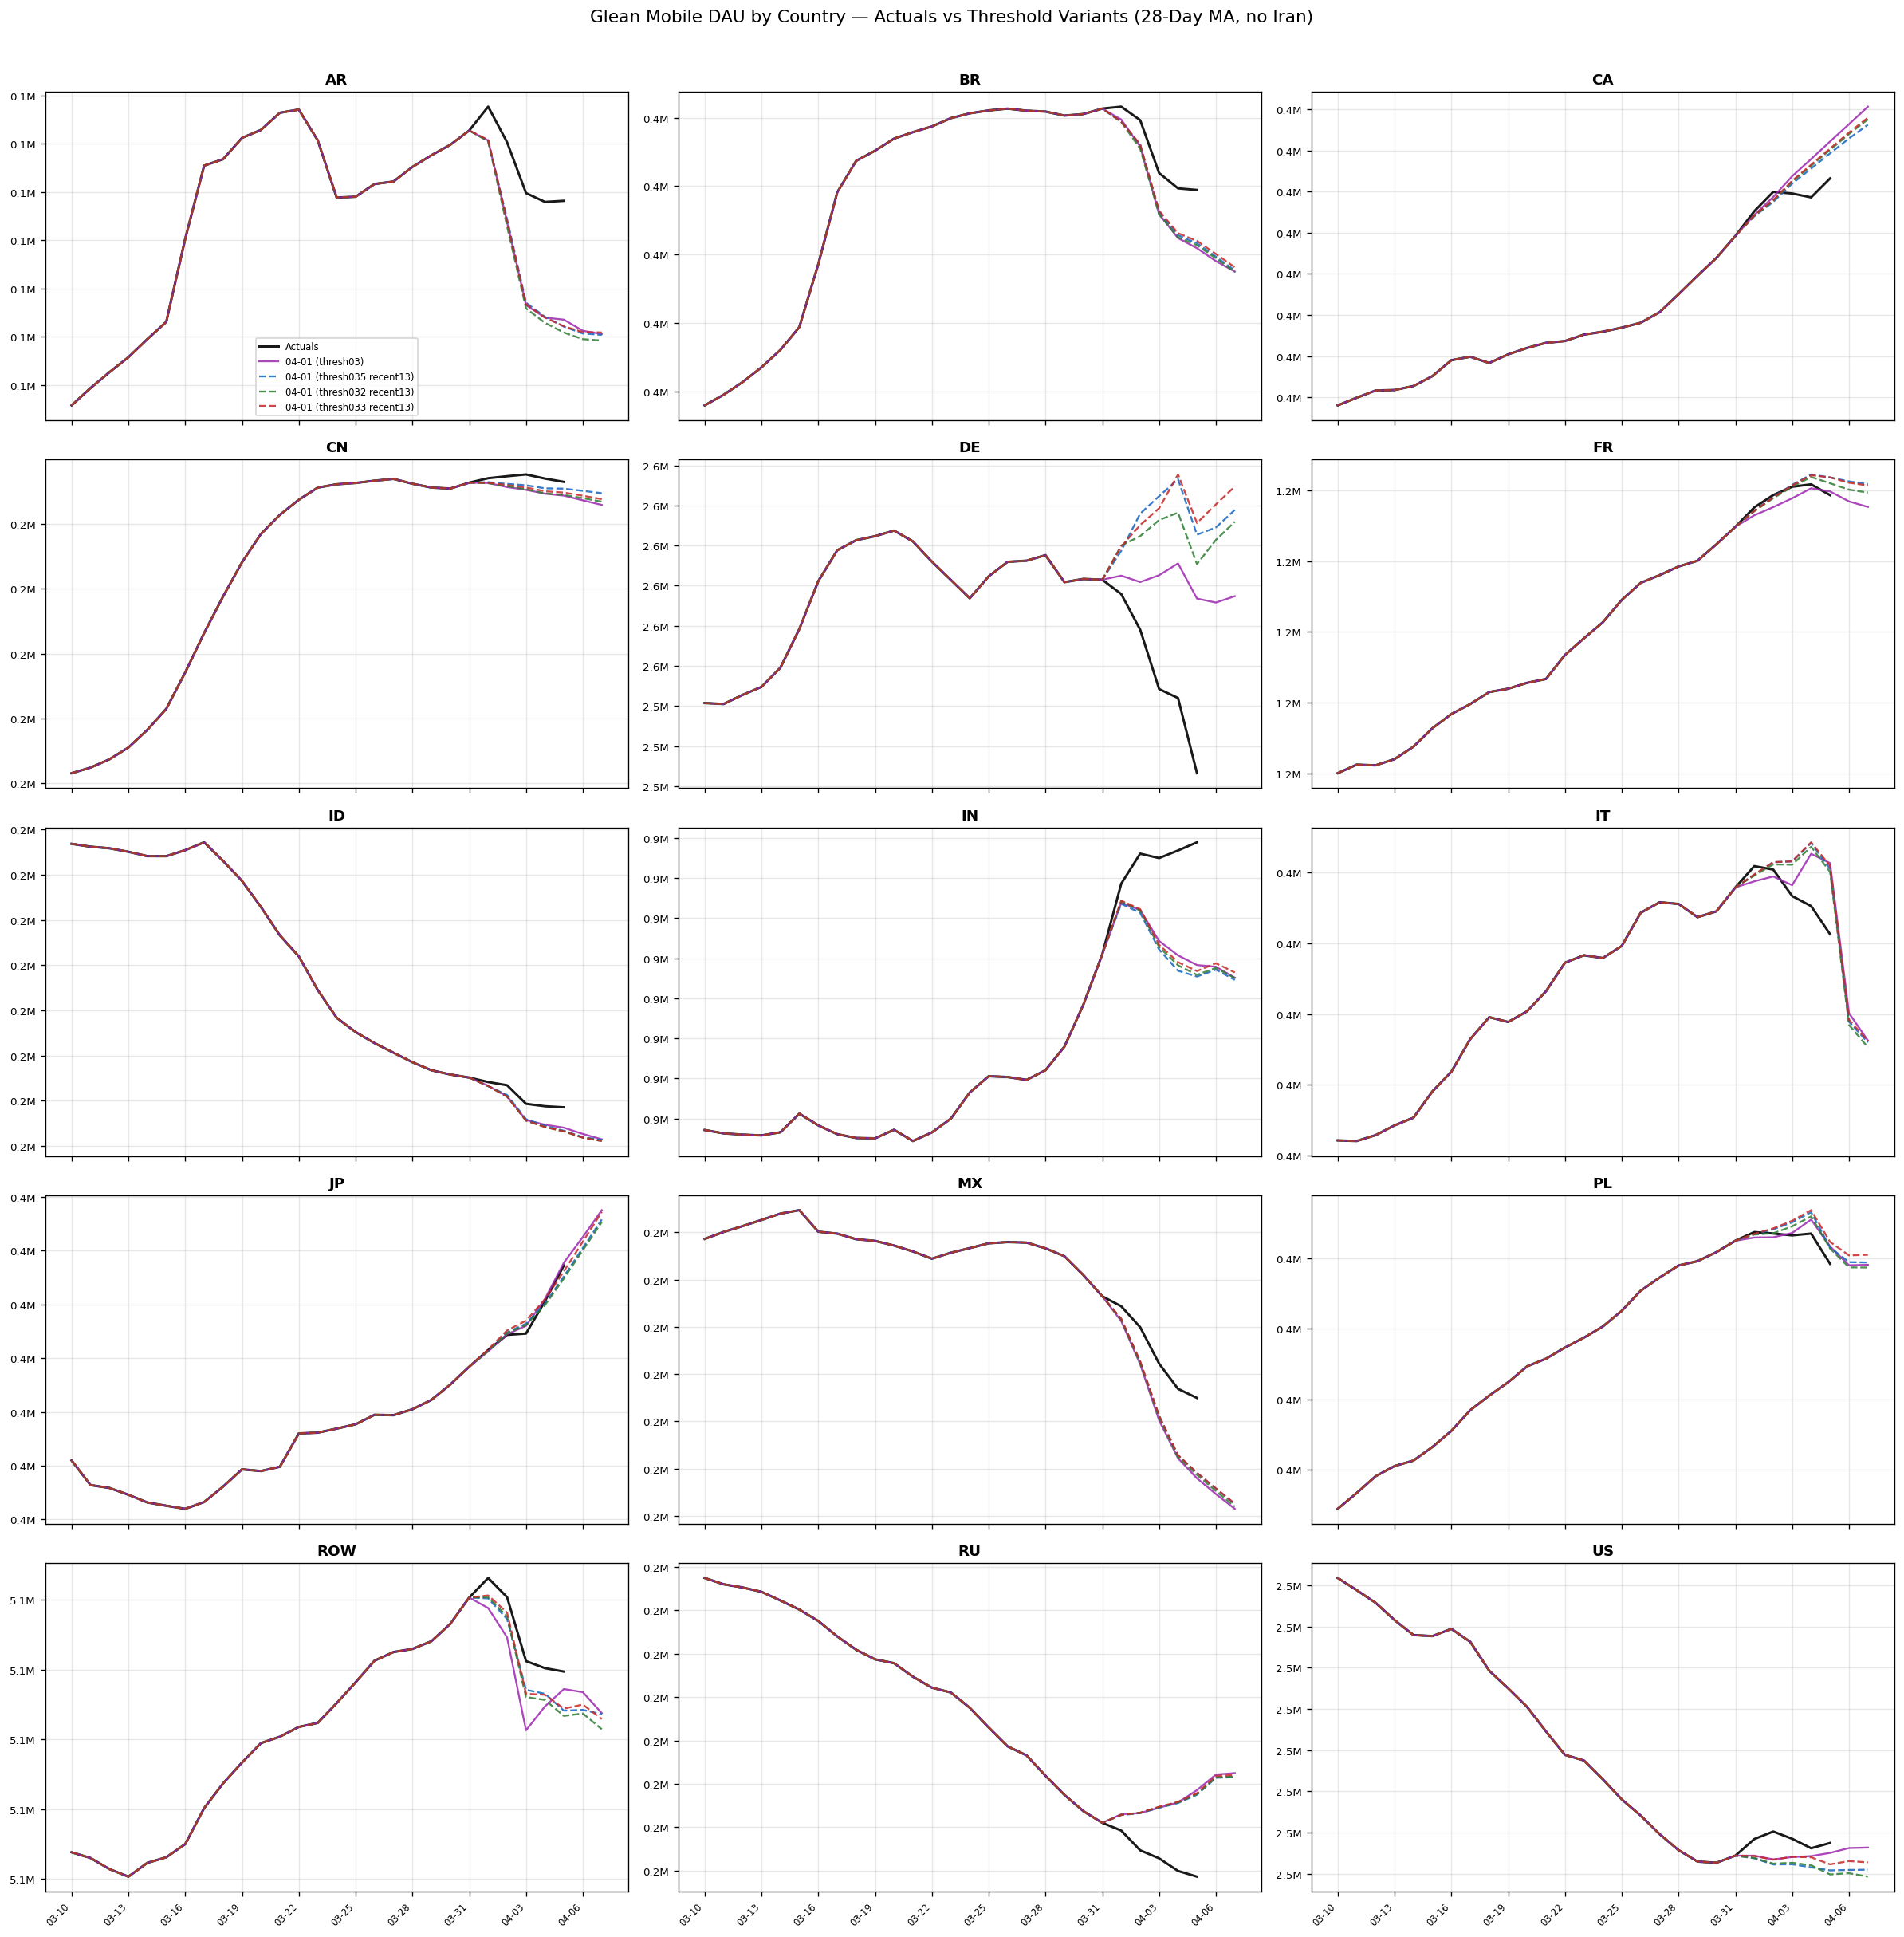

In [535]:
# [plot-country-grid]
COUNTRY_ZOOM_START = pd.Timestamp('2026-03-10')
COUNTRY_ZOOM_END = pd.Timestamp('2026-04-07')

first_variant = next(iter(country_data))
countries_to_plot = sorted(
    c for c in country_data[first_variant]['country'].unique()
    if c != 'ALL'
)

n_countries = len(countries_to_plot)
n_cols = 3
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharex=True)
axes_flat = axes.flatten()

for idx, country in enumerate(countries_to_plot):
    ax = axes_flat[idx]

    # Actuals
    actuals_c = df_country_actuals[
        (df_country_actuals['country'] == country)
        & (df_country_actuals['date'] >= COUNTRY_ZOOM_START)
        & (df_country_actuals['date'] <= COUNTRY_ZOOM_END)
    ]
    ax.plot(actuals_c['date'], actuals_c['dau_ma28'],
            color='black', linewidth=1.8, alpha=0.9, label='Actuals')

    # Forecast variants
    for key, style in COUNTRY_STYLES.items():
        df_c = country_data[key]
        df_c = df_c[df_c['country'] == country].copy()
        df_c = df_c.sort_values('target_date')
        df_c['dau_ma28'] = df_c['dau'].rolling(28, min_periods=28).mean()
        df_c = df_c[
            (df_c['target_date'] >= COUNTRY_ZOOM_START)
            & (df_c['target_date'] <= COUNTRY_ZOOM_END)
        ]
        ax.plot(df_c['target_date'], df_c['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=key)

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.tick_params(axis='both', labelsize=8)

    if idx == 0:
        ax.legend(fontsize=7, loc='best')

# Hide unused subplots
for idx in range(n_countries, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Format x-axis on bottom row
for ax in axes_flat:
    if ax.get_visible():
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

fig.suptitle('Glean Mobile DAU by Country — Actuals vs Threshold Variants (28-Day MA, no Iran)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


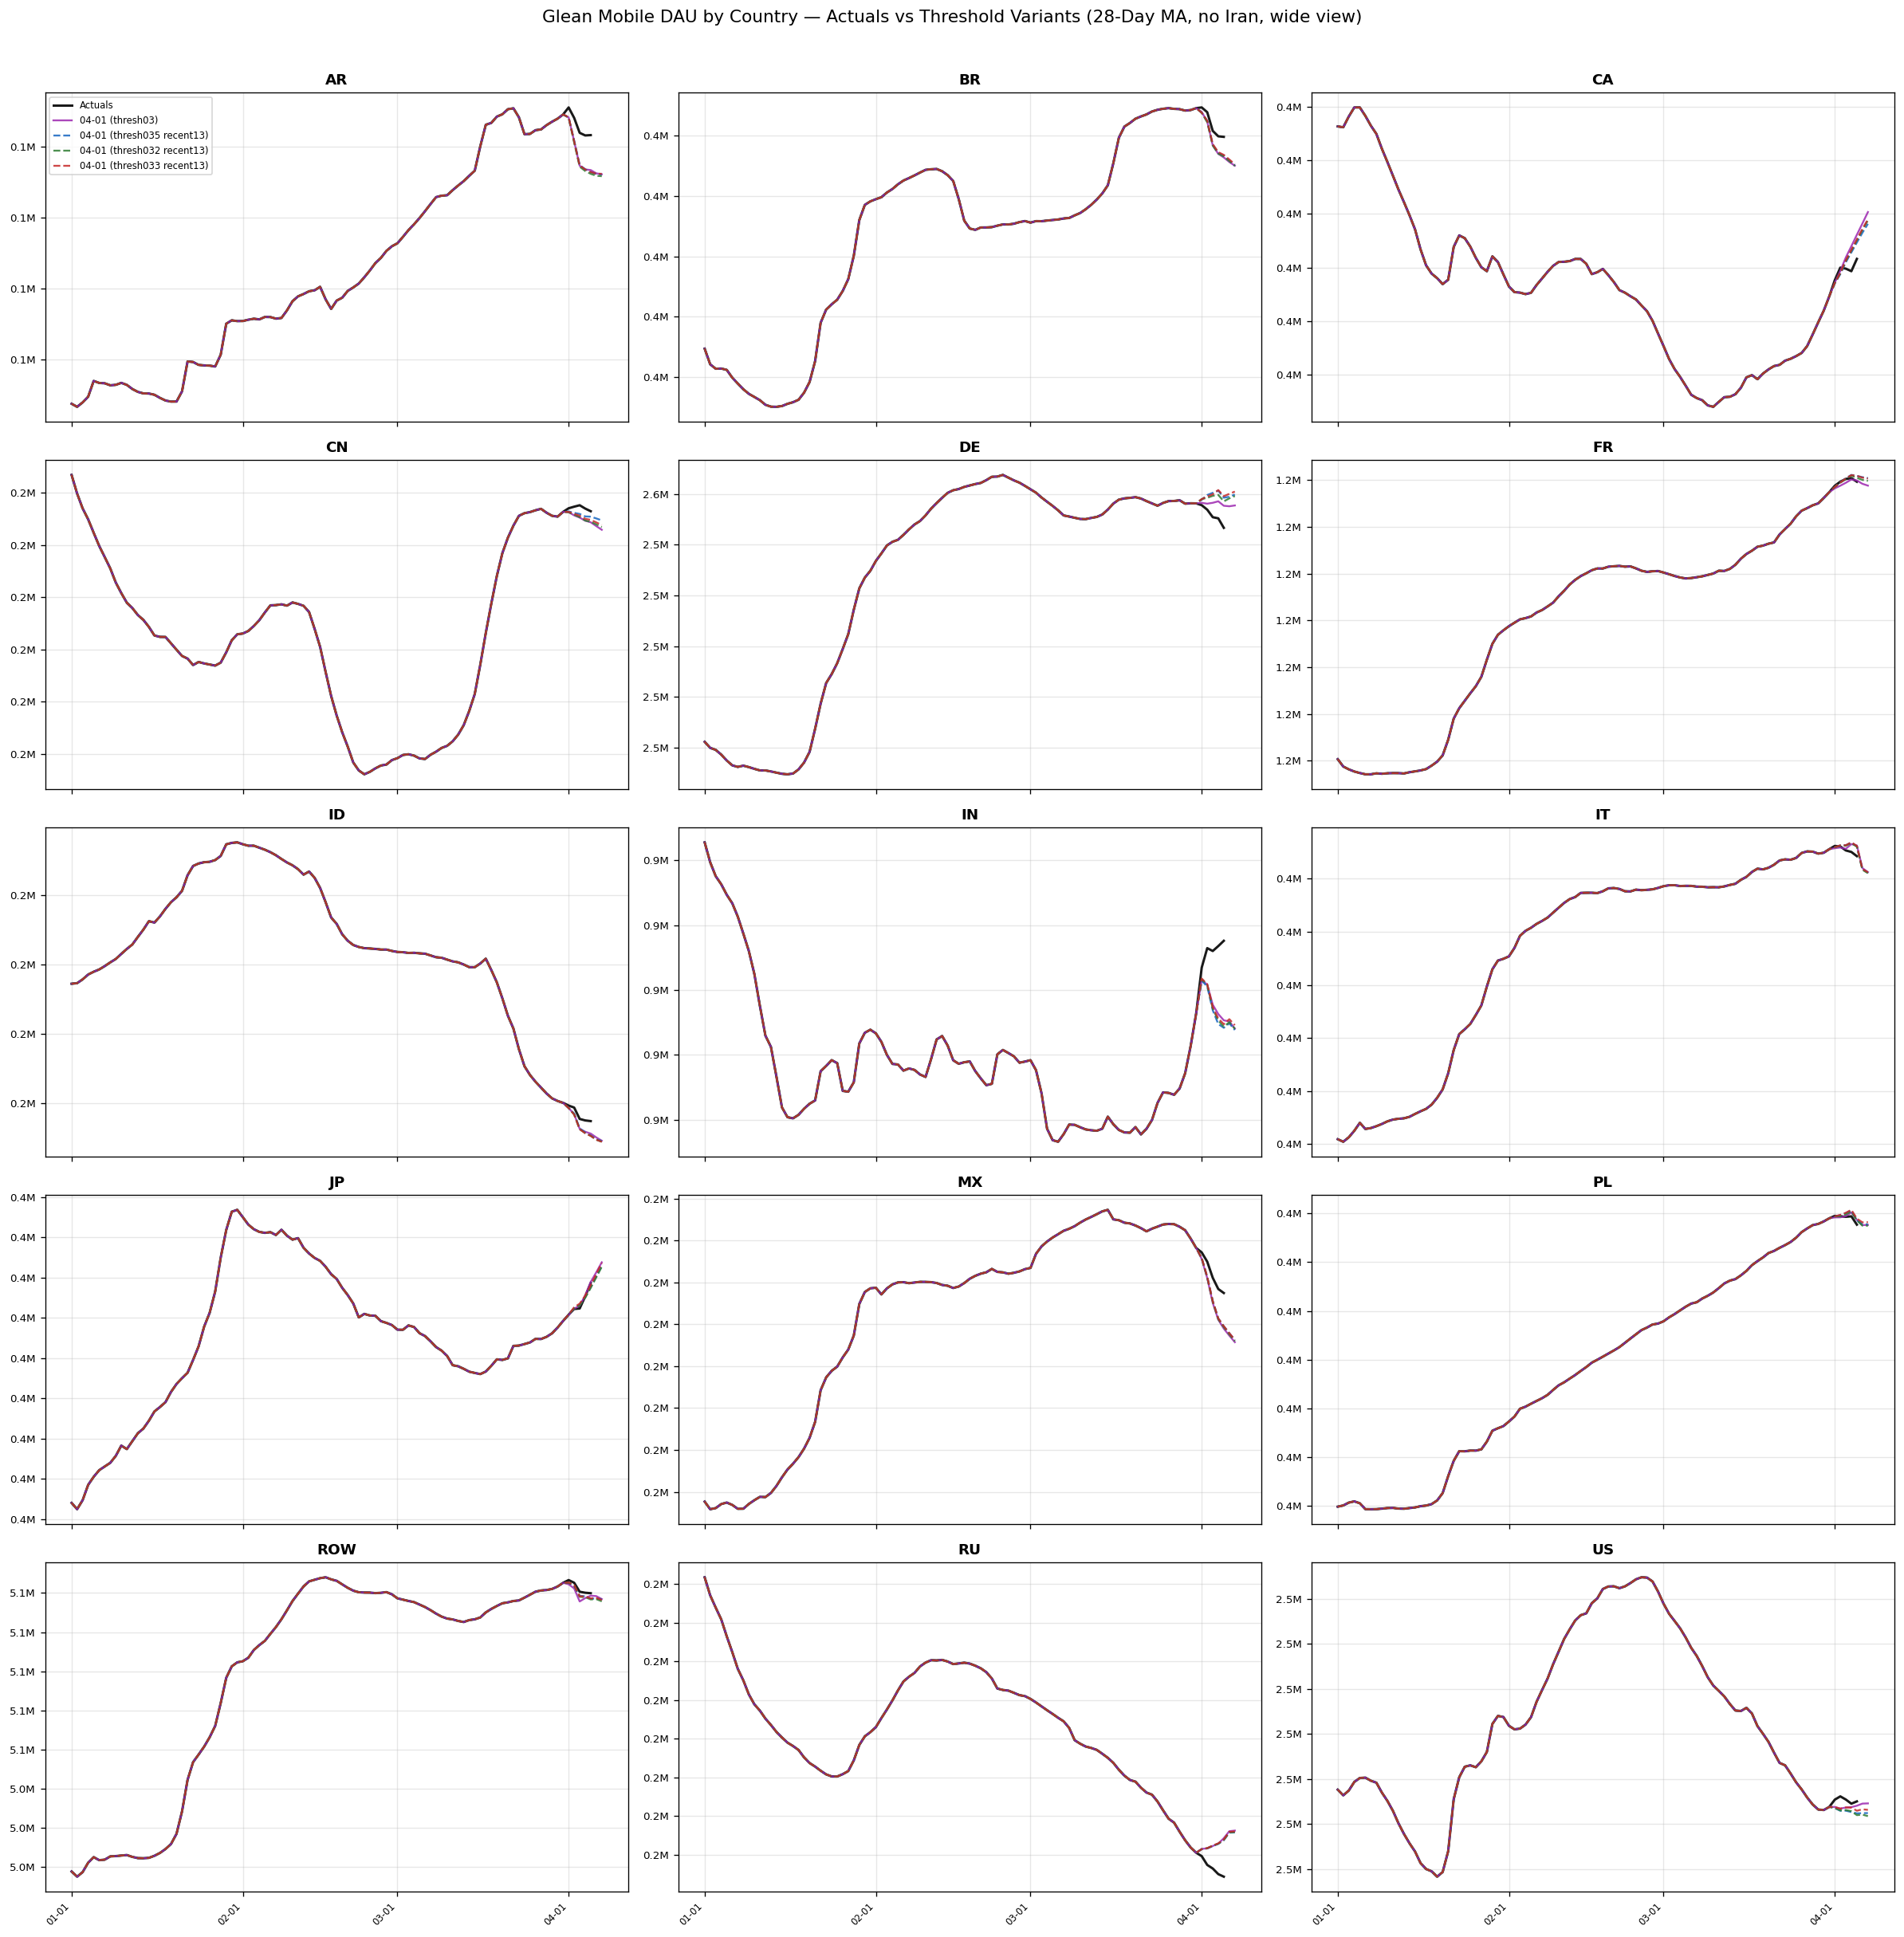

In [536]:
# [plot-country-grid-wide]
COUNTRY_WIDE_START = pd.Timestamp('2026-01-01')
COUNTRY_WIDE_END = pd.Timestamp('2026-04-07')

first_variant = next(iter(country_data))
countries_to_plot = sorted(
    c for c in country_data[first_variant]['country'].unique()
    if c != 'ALL'
)

n_countries = len(countries_to_plot)
n_cols = 3
n_rows = (n_countries + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharex=True)
axes_flat = axes.flatten()

for idx, country in enumerate(countries_to_plot):
    ax = axes_flat[idx]

    # Actuals
    actuals_c = df_country_actuals[
        (df_country_actuals['country'] == country)
        & (df_country_actuals['date'] >= COUNTRY_WIDE_START)
        & (df_country_actuals['date'] <= COUNTRY_WIDE_END)
    ]
    ax.plot(actuals_c['date'], actuals_c['dau_ma28'],
            color='black', linewidth=1.8, alpha=0.9, label='Actuals')

    # Forecast variants
    for key, style in COUNTRY_STYLES.items():
        df_c = country_data[key]
        df_c = df_c[df_c['country'] == country].copy()
        df_c = df_c.sort_values('target_date')
        df_c['dau_ma28'] = df_c['dau'].rolling(28, min_periods=28).mean()
        df_c = df_c[
            (df_c['target_date'] >= COUNTRY_WIDE_START)
            & (df_c['target_date'] <= COUNTRY_WIDE_END)
        ]
        ax.plot(df_c['target_date'], df_c['dau_ma28'],
                color=style['color'], linestyle=style['linestyle'],
                linewidth=style['linewidth'], alpha=0.85,
                label=key)

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.tick_params(axis='both', labelsize=8)

    if idx == 0:
        ax.legend(fontsize=7, loc='best')

# Hide unused subplots
for idx in range(n_countries, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Format x-axis on bottom row
for ax in axes_flat:
    if ax.get_visible():
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

fig.suptitle('Glean Mobile DAU by Country — Actuals vs Threshold Variants (28-Day MA, no Iran, wide view)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [538]:
# # [plot-clip-comparison]
# # Direct comparison: thresh03 vs thresh03 recent13 (raw daily DAU)
# CLIP_START = pd.Timestamp('2026-03-15')
# CLIP_END = pd.Timestamp('2026-04-30')

# base_key = '04-01 (thresh03)'
# compare_key = '04-01 (thresh03 recent13)'

# df_base = mobile_data[base_key].copy()
# df_compare = mobile_data[compare_key].copy()

# merged = df_base[['target_date', 'dau']].merge(
#     df_compare[['target_date', 'dau']],
#     on='target_date', suffixes=('_base', '_compare')
# )
# merged['diff'] = merged['dau_compare'] - merged['dau_base']
# merged['pct_diff'] = 100 * merged['diff'] / merged['dau_base']
# merged = merged[
#     (merged['target_date'] >= CLIP_START)
#     & (merged['target_date'] <= CLIP_END)
# ]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
#                                 gridspec_kw={'height_ratios': [2, 1]})

# # Top: raw DAU for both variants
# ax1.plot(merged['target_date'], merged['dau_base'],
#          color='#9C27B0', linewidth=1.6, label=base_key)
# ax1.plot(merged['target_date'], merged['dau_compare'],
#          color='#F57F17', linewidth=1.6, label=compare_key)
# ax1.set_title(f'World Mobile DAU — {base_key} vs {compare_key} (Raw Daily)')
# ax1.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
# ax1.legend(fontsize=9)

# # Bottom: difference (compare - base)
# ax2.bar(merged['target_date'], merged['diff'], color='#F57F17', alpha=0.7, width=0.8)
# ax2.axhline(0, color='black', linewidth=0.5)
# ax2.set_title(f'Difference ({compare_key} − {base_key})')
# ax2.set_ylabel('DAU diff')
# ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e3:+,.0f}k'))

# ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
# plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# plt.tight_layout()
# plt.show()

# # Print the peak differences
# peak = merged.loc[merged['diff'].abs().idxmax()]
# print(f"Peak difference: {peak['diff']:+,.0f} DAU ({peak['pct_diff']:+.2f}%) on {peak['target_date'].date()}")


## Plus-Iran Comparison

Compare plus-Iran forecasts (no-Iran forecast + synthetic Iran values) against actuals **including** Iran.


In [539]:
# [load-plus-iran]
PLUS_IRAN_DIR = 'data-official/comparisons/no-iran'
APRIL_DIR = 'data-official/comparisons/april'

PLUS_IRAN_FILES = {
    'april 02-27 (baseline)': f'{APRIL_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.parquet',
    'plus-iran 02-27': f'{PLUS_IRAN_DIR}/2026-02-27/mozaic_daily_forecast.2026-02-27.gm+ld-D.plus_iran.parquet',
    'plus-iran 04-01 (thresh032 recent13)': f'{PLUS_IRAN_DIR}/2026-04-01_cps0.02_thresh032_recent13/mozaic_daily_forecast.2026-04-01.gm-D.plus_iran.parquet',
}

PLUS_IRAN_STYLES = {
    'april 02-27 (baseline)':      {'color': 'black',   'linestyle': '-',  'linewidth': 2.2},
    'plus-iran 02-27':             {'color': '#1565C0', 'linestyle': '-',  'linewidth': 2.0},
    'plus-iran 04-01 (thresh032 recent13)':  {'color': '#2E7D32', 'linestyle': '--', 'linewidth': 1.6},
}

plus_iran_data = {}
for key, path in PLUS_IRAN_FILES.items():
    plus_iran_data[key] = extract_world_mobile_dau(path)
    date_range = f"{plus_iran_data[key]['target_date'].min().date()} to {plus_iran_data[key]['target_date'].max().date()}"
    print(f'{key:30s}: {len(plus_iran_data[key]):>5} rows  [{date_range}]')


april 02-27 (baseline)        :  2557 rows  [2020-12-31 to 2027-12-31]
plus-iran 02-27               :  2557 rows  [2020-12-31 to 2027-12-31]
plus-iran 04-01 (thresh032 recent13):  2557 rows  [2020-12-31 to 2027-12-31]


In [540]:
# [query-actuals-with-iran]
# Query BQ for actual world-level mobile DAU (all apps combined, INCLUDING Iran).
import time
from pathlib import Path
from google.cloud import bigquery

ACTUALS_WITH_IRAN_END = "2026-04-06"

QUERY_MOBILE_ACTUALS_WITH_IRAN = f"""
SELECT
    submission_date AS date,
    SUM(dau) AS dau
FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
  AND submission_date BETWEEN '2020-12-31' AND '{ACTUALS_WITH_IRAN_END}'
GROUP BY submission_date
ORDER BY 1
"""

checkpoint_actuals_with_iran = CHECKPOINT_DIR / "compare_mobile_actuals_with_iran.parquet"
if checkpoint_actuals_with_iran.exists():
    print(f"Loading checkpoint: {checkpoint_actuals_with_iran}")
    df_actuals_with_iran = pd.read_parquet(checkpoint_actuals_with_iran)
    print(f"Loaded | Rows: {len(df_actuals_with_iran):,} | {df_actuals_with_iran['date'].min()} to {df_actuals_with_iran['date'].max()}")
else:
    print("Querying BigQuery (mobile actuals, with Iran)...")
    t0 = time.time()
    df_actuals_with_iran = bigquery.Client(PROJECT).query(QUERY_MOBILE_ACTUALS_WITH_IRAN).to_dataframe()
    elapsed = time.time() - t0
    print(f"Query complete | {elapsed:.1f}s | Rows: {len(df_actuals_with_iran):,}")
    df_actuals_with_iran.to_parquet(checkpoint_actuals_with_iran)
    print(f"Saved to {checkpoint_actuals_with_iran}")

df_actuals_with_iran['date'] = pd.to_datetime(df_actuals_with_iran['date'])
df_actuals_with_iran = df_actuals_with_iran.sort_values('date').reset_index(drop=True)
df_actuals_with_iran['dau_ma28'] = df_actuals_with_iran['dau'].rolling(28, min_periods=28).mean()

print(f"\nDate range: {df_actuals_with_iran['date'].min().date()} to {df_actuals_with_iran['date'].max().date()}")
print(f"Last 5 days MA28:")
print(df_actuals_with_iran[['date', 'dau', 'dau_ma28']].tail(5).to_string(index=False))


Loading checkpoint: data/compare_mobile_actuals_with_iran.parquet
Loaded | Rows: 1,923 | 2020-12-31 to 2026-04-06

Date range: 2020-12-31 to 2026-04-06
Last 5 days MA28:
      date      dau     dau_ma28
2026-04-02 15402110 1.531132e+07
2026-04-03 15043164 1.529994e+07
2026-04-04 14804627 1.529779e+07
2026-04-05 14671237 1.529255e+07
2026-04-06 15298086 1.528725e+07


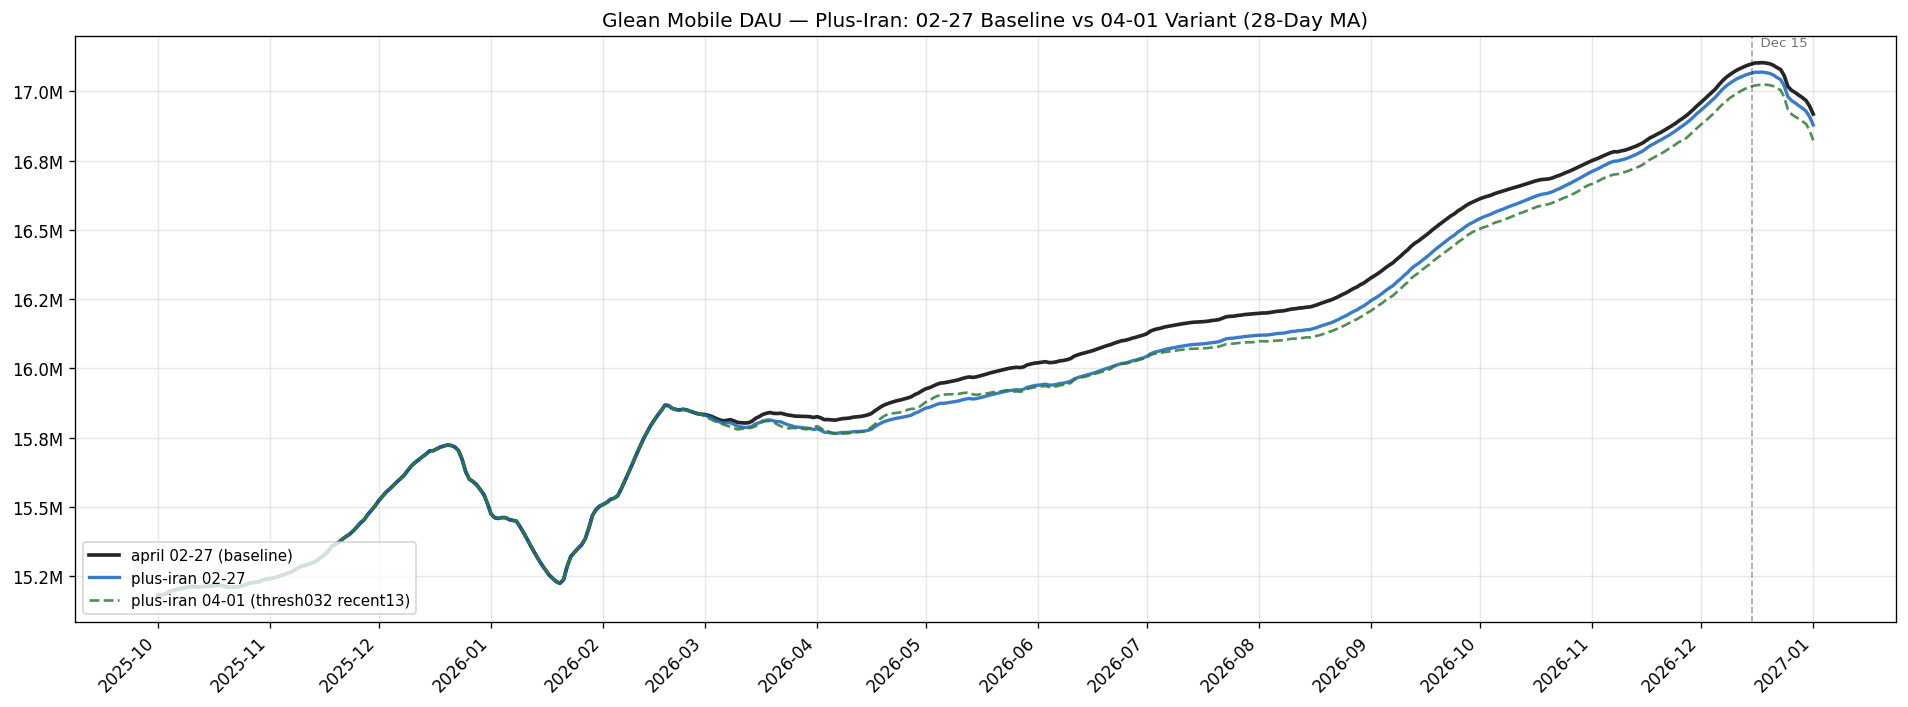

In [541]:
# [plot-plus-iran-all]
fig, ax = plt.subplots(figsize=(16, 6))

for key in PLUS_IRAN_FILES:
    style = PLUS_IRAN_STYLES[key]
    df_ma = add_ma28(plus_iran_data[key])
    df_plot = trim(df_ma)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — Plus-Iran: 02-27 Baseline vs 04-01 Variant (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='lower left', fontsize=9)
mark_accounting_date(ax)
apply_date_axis(ax)

plt.tight_layout()
plt.show()


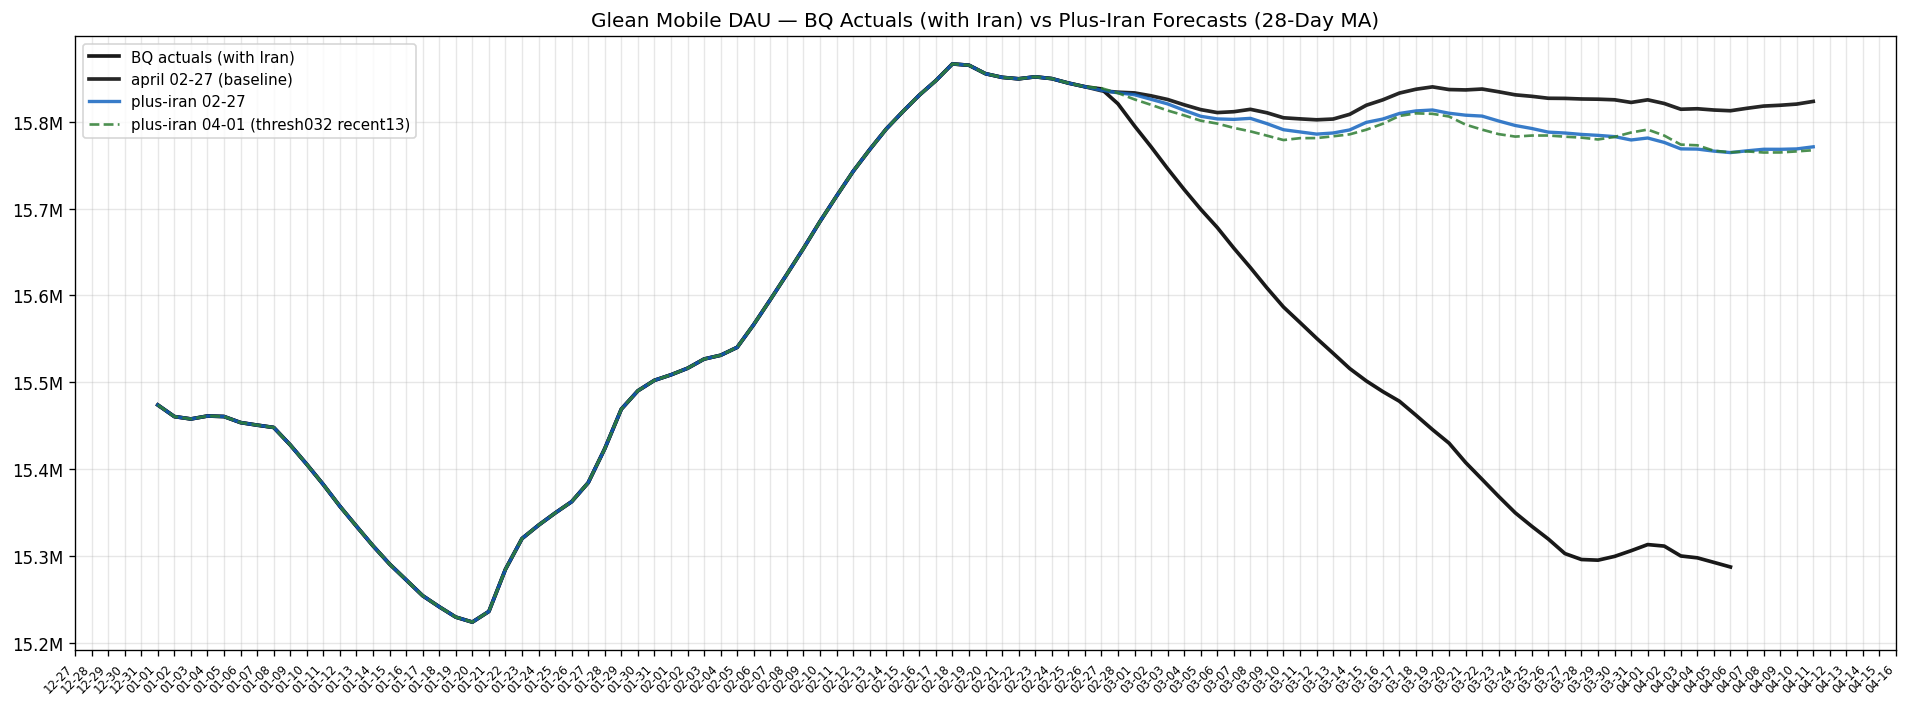

In [542]:
# [plot-plus-iran-actuals-long]
PLUS_IRAN_ZOOM_START = pd.Timestamp('2026-01-01')
PLUS_IRAN_ZOOM_END = pd.Timestamp('2026-04-11')

fig, ax = plt.subplots(figsize=(16, 6))

# Plot actuals WITH Iran (thick black line)
actuals_iran_plot = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= PLUS_IRAN_ZOOM_START)
    & (df_actuals_with_iran['date'] <= PLUS_IRAN_ZOOM_END)
]
ax.plot(actuals_iran_plot['date'], actuals_iran_plot['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

# Plot plus-iran forecast lines
for key in PLUS_IRAN_FILES:
    style = PLUS_IRAN_STYLES[key]
    df_ma = add_ma28(plus_iran_data[key])
    df_plot = trim(df_ma, start=PLUS_IRAN_ZOOM_START, end=PLUS_IRAN_ZOOM_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals (with Iran) vs Plus-Iran Forecasts (28-Day MA)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


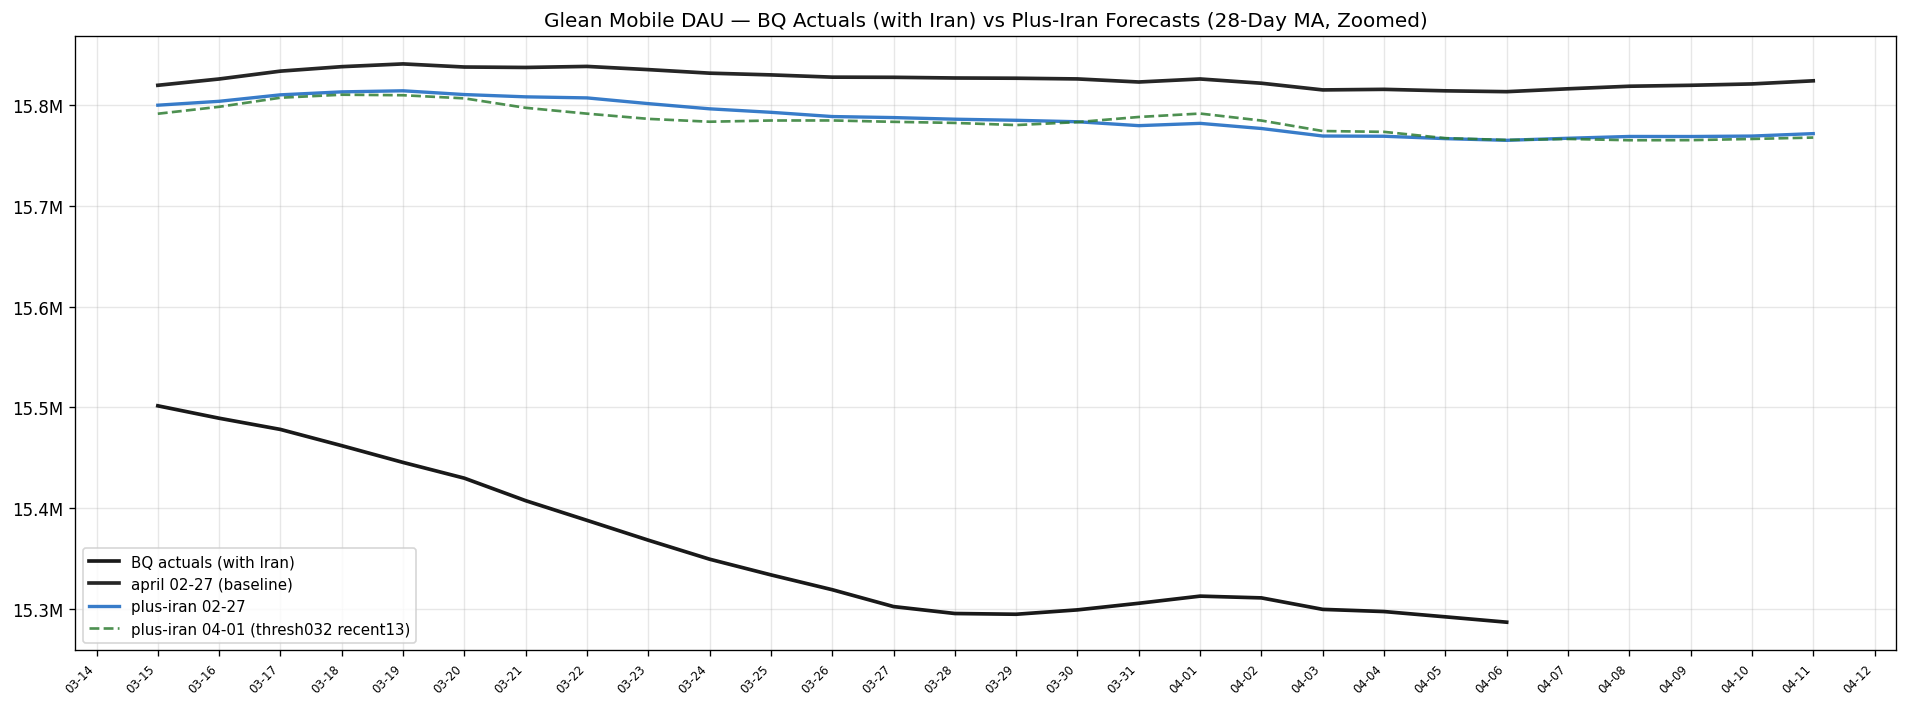

In [543]:
# [plot-plus-iran-actuals-zoom]
PLUS_IRAN_CLOSE_START = pd.Timestamp('2026-03-15')
PLUS_IRAN_CLOSE_END = pd.Timestamp('2026-04-11')

fig, ax = plt.subplots(figsize=(16, 6))

# Plot actuals WITH Iran (thick black line)
actuals_iran_zoom = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= PLUS_IRAN_CLOSE_START)
    & (df_actuals_with_iran['date'] <= PLUS_IRAN_CLOSE_END)
]
ax.plot(actuals_iran_zoom['date'], actuals_iran_zoom['dau_ma28'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

# Plot plus-iran forecast lines
for key in PLUS_IRAN_FILES:
    style = PLUS_IRAN_STYLES[key]
    df_ma = add_ma28(plus_iran_data[key])
    df_plot = trim(df_ma, start=PLUS_IRAN_CLOSE_START, end=PLUS_IRAN_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau_ma28'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals (with Iran) vs Plus-Iran Forecasts (28-Day MA, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


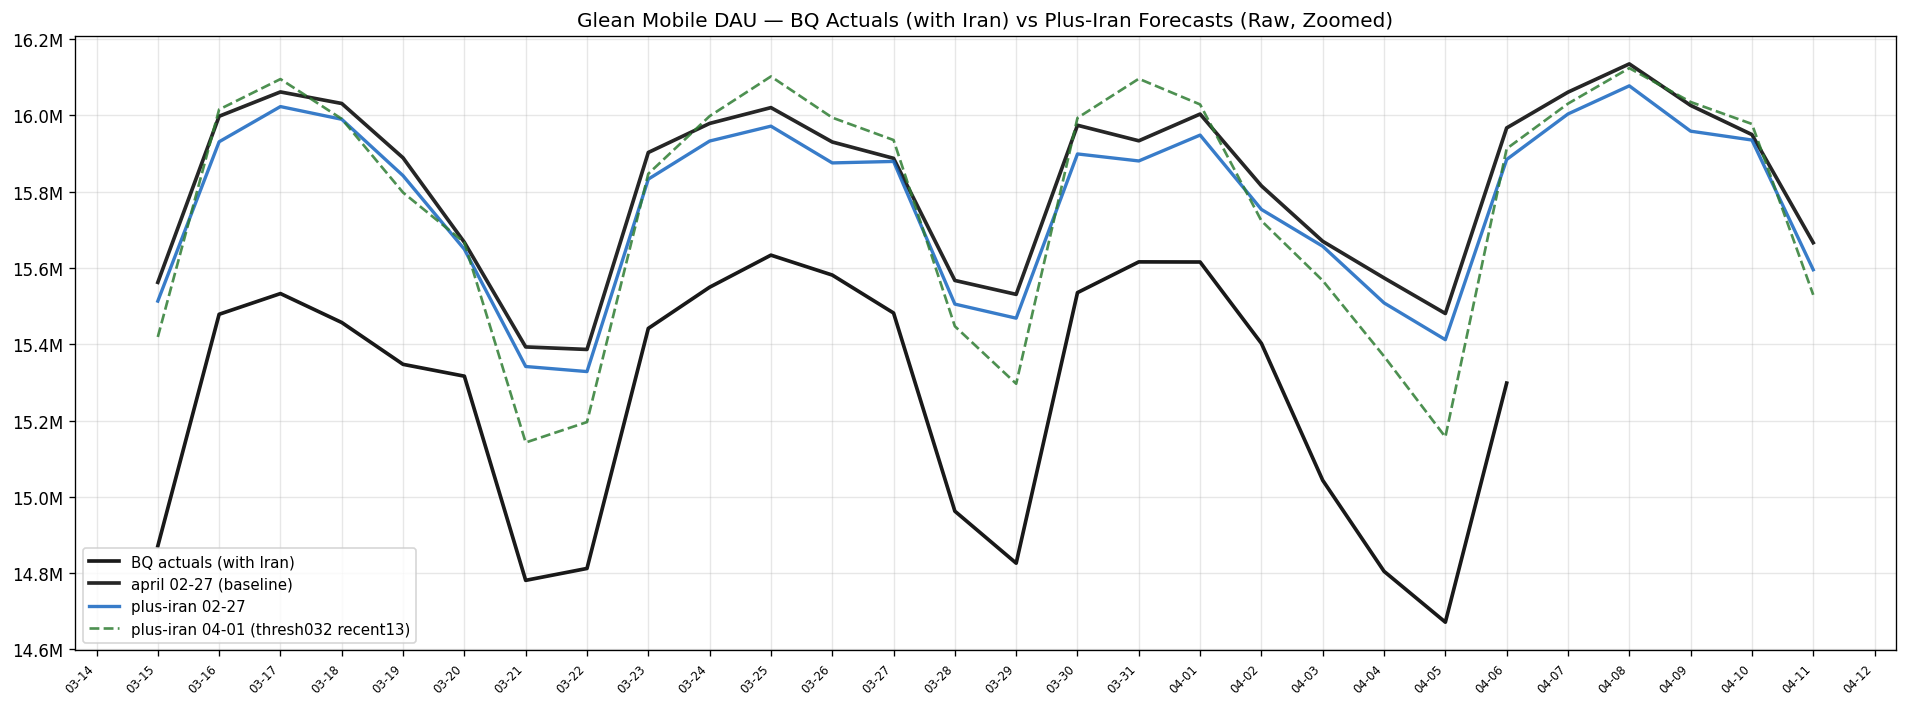

In [544]:
# [plot-plus-iran-raw]
fig, ax = plt.subplots(figsize=(16, 6))

# Actuals raw WITH Iran
actuals_iran_raw = df_actuals_with_iran[
    (df_actuals_with_iran['date'] >= PLUS_IRAN_CLOSE_START)
    & (df_actuals_with_iran['date'] <= PLUS_IRAN_CLOSE_END)
]
ax.plot(actuals_iran_raw['date'], actuals_iran_raw['dau'],
        color='black', linestyle='-', linewidth=2.2, alpha=0.9,
        label='BQ actuals (with Iran)')

# All plus-iran forecast variants raw
for key in PLUS_IRAN_FILES:
    style = PLUS_IRAN_STYLES[key]
    df_plot = trim(plus_iran_data[key], start=PLUS_IRAN_CLOSE_START, end=PLUS_IRAN_CLOSE_END)
    ax.plot(df_plot['target_date'], df_plot['dau'],
            color=style['color'], linestyle=style['linestyle'],
            linewidth=style['linewidth'], alpha=0.85,
            label=key)

ax.set_title('Glean Mobile DAU — BQ Actuals (with Iran) vs Plus-Iran Forecasts (Raw, Zoomed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
ax.legend(loc='best', fontsize=9)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()


In [545]:
# [plus-iran-ma28-dec15]
PLUS_IRAN_SNAPSHOT = pd.Timestamp('2026-12-15')

print(f'28-day MA on {PLUS_IRAN_SNAPSHOT.date()} (plus-Iran):')
print()

baseline_key = 'april 02-27 (baseline)'
baseline_ma = add_ma28(plus_iran_data[baseline_key])
baseline_row = baseline_ma.loc[baseline_ma['target_date'] == PLUS_IRAN_SNAPSHOT]
baseline_val = baseline_row['dau_ma28'].values[0] if len(baseline_row) else np.nan

header = f"  {'Variant':<30s}  {'MA28':>14s}  {'Diff':>12s}  {'Pct':>8s}"
print(header)
print(f"  {'-'*30}  {'-'*14}  {'-'*12}  {'-'*8}")
print(f"  {baseline_key:<30s}  {baseline_val:>14,.0f}  {'—':>12s}  {'—':>8s}")

for key in PLUS_IRAN_FILES:
    if key == baseline_key:
        continue
    df_ma = add_ma28(plus_iran_data[key])
    row = df_ma.loc[df_ma['target_date'] == PLUS_IRAN_SNAPSHOT]
    if len(row) == 0:
        print(f"  {key:<30s}:  no data for this date")
    else:
        val = row['dau_ma28'].values[0]
        diff = val - baseline_val
        pct = 100 * diff / baseline_val
        print(f"  {key:<30s}  {val:>14,.0f}  {diff:>+12,.0f}  {pct:>+7.2f}%")


28-day MA on 2026-12-15 (plus-Iran):

  Variant                                   MA28          Diff       Pct
  ------------------------------  --------------  ------------  --------
  april 02-27 (baseline)              17,099,219             —         —
  plus-iran 02-27                     17,066,122       -33,097    -0.19%
  plus-iran 04-01 (thresh032 recent13)      17,018,535       -80,683    -0.47%
